In [2]:
# 변수의 shape, type, value 확인
def p(var,_str='') :
    if _str=='\n' or _str=='cr' :
        _str = '\n'
    else :
        print(f'[{_str}]:')
        _str = ''
    if type(var)!=type([]):
        try:
            print(f'Shape:{var.shape}')
        except :
            pass
    print(f'Type: {type(var)}')
    print(f'Values: {var}'+_str)

def pst(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}, {type(_x)}')
def ps(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}')

In [3]:
%%capture
!pip -q install lightning torchinfo

## **Import Module**

In [4]:
import torch
from torch import nn
from torch.nn import functional as F
from torchmetrics import functional as FM
from torch.utils.data import DataLoader, random_split
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import v2
import torchvision
from torchinfo import summary

import lightning as L
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

device ='cuda:0'
torch.__version__,L.__version__

('2.8.0+cu126', '2.5.5')

## **DataSet**

In [5]:
%%capture
# https://github.com/FinanceData/FinanceDataReader
!pip install finance-datareader

In [6]:
import FinanceDataReader as fdr

# KOSPI
#pd_data = fdr.DataReader('KS11', '2000-01-01')

# Samsung(005930), 1992-01-01 ~ 2018-10-31
pd_data = fdr.DataReader('005930', '2015-01-01')
# (Open,High,Low,Close,Volume,change)
pd_data = pd_data.drop(columns=['Change'])
pd_data.head(),pd_data.tail()

(             Open   High    Low  Close  Volume
 Date                                          
 2015-01-02  26799  26799  26540  26600  175499
 2015-01-05  26720  26720  26260  26660  202790
 2015-01-06  26300  26340  25760  25900  304710
 2015-01-07  25880  26220  25640  26140  286455
 2015-01-08  26780  26780  26199  26280  289552,
               Open    High     Low   Close    Volume
 Date                                                
 2025-10-23   96800   98500   96300   96500  18488581
 2025-10-24   97900   99000   97700   98800  18801925
 2025-10-27  101300  102000  100600  102000  22169970
 2025-10-28  100900  101000   99100   99500  20002282
 2025-10-29  100200  101000   99100  100500  20646412)

### Preprocessing

In [7]:
pd_data.describe()

,Open,High,Low,Close,Volume
count,2657.000000,2657.000000,2657.000000,2657.000000,2.657000e+03
mean,54160.679714,54677.374106,53633.960482,54199.461799,1.158810e+07
std,17730.262425,17862.272032,17562.005764,17604.264464,1.024798e+07
min,0.000000,0.000000,0.000000,21340.000000,0.000000e+00
25%,43700.000000,44100.000000,43100.000000,43750.000000,3.009000e+05
50%,54400.000000,55000.000000,53800.000000,54300.000000,1.157564e+07
75%,68800.000000,69700.000000,68300.000000,68900.000000,1.708089e+07
max,101300.000000,102000.000000,100600.000000,102000.000000,9.030618e+07


<Axes: xlabel='Date'>

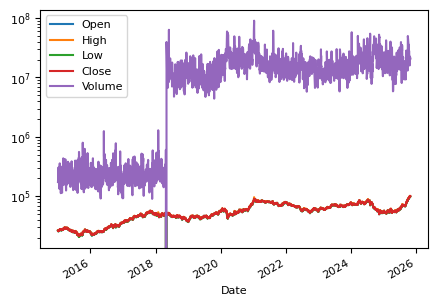

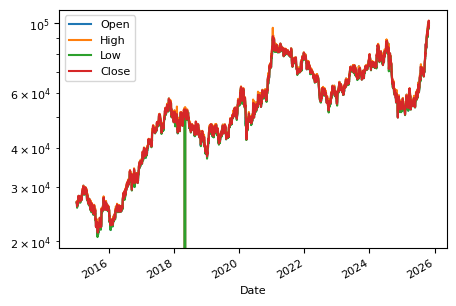

In [8]:
pd_data.plot(y=['Open','High','Low','Close','Volume'],logy=True)
pd_data.plot(y=['Open','High','Low','Close'],logy=True)

In [9]:
pd_data['Open'] = pd_data["Open"].replace(0,np.nan)
pd_data['High'] = pd_data["High"].replace(0,np.nan)
pd_data['Low'] = pd_data["Low"].replace(0,np.nan)
pd_data['Volume'] = pd_data["Volume"].replace(0,np.nan)

<Axes: xlabel='Date'>

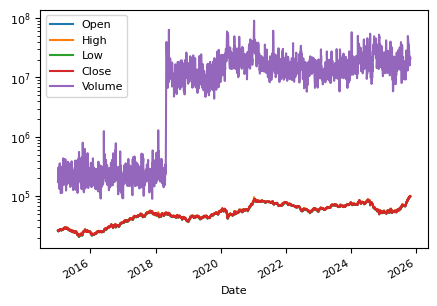

In [10]:
pd_data['Open']=pd_data['Open'].interpolate()
pd_data['High']=pd_data['High'].interpolate()
pd_data['Low']=pd_data['Low'].interpolate()
pd_data['Volume']=pd_data['Volume'].interpolate()
pd_data.plot(logy=True)

### Technical indicator 추가

https://technical-analysis-library-in-python.readthedocs.io/en/latest/#  
It is a Technical Analysis library to financial time series datasets (open, close, high, low, volume).   
You can use it to do feature engineering from financial datasets. It is built on Python Pandas library.  

In [11]:
%%capture
!pip install ta

In [12]:
import ta

In [13]:
close = pd_data["Close"]
high = pd_data["High"]
low = pd_data["Low"]

In [ ]:
window=20
pd_data[f'ema_{window}']=ta.trend.ema_indicator(close, window=window)
window=5
pd_data[f'ma_{window}']=ta.trend.SMAIndicator(close, window=window).sma_indicator()
window=10
pd_data[f'ma_{window}']=ta.trend.SMAIndicator(close, window=window).sma_indicator()
lbp = 14
pd_data[f"will_r_{lbp}"]= ta.momentum.WilliamsRIndicator(high, low, close, lbp= 14).williams_r()

window = 26
pd_data[f"macd_{window}"] = ta.trend.MACD(close, window_slow= window, window_fast= 12, window_sign= 9).macd()
pd_data[f"macd_diff_{window}"] = ta.trend.macd_diff(close, window_slow=26, window_fast=12, window_sign=9)
pd_data[f"macd_signal_{window}"] = ta.trend.macd_signal(close, window_slow=26, window_fast=12, window_sign=9)
# window = 20
# pd_data[f"cci_{window}"]=ta.trend.CCIIndicator(high, low, close, window= window, constant= 0.015).cci()
# window = 14
# pd_data[f"atr_{window}"]=ta.volatility.AverageTrueRange(high, low, close, window = window).average_true_range()
# window = 20
# windev = 2
# pd_data['bb_high_band']=ta.volatility.BollingerBands(close, window= window, window_dev= windev).bollinger_hband()
# pd_data['bb_low_band']=ta.volatility.BollingerBands(close, window= window, window_dev= windev).bollinger_lband()
# pd_data['bb_high_indicator']=ta.volatility.BollingerBands(close, window= window, window_dev= windev).bollinger_hband_indicator()
# pd_data['bb_low_indicator']=ta.volatility.BollingerBands(close, window= window, window_dev= windev).bollinger_lband_indicator()
# window = 12
# pd_data[f"roc_{window}"] = ta.momentum.ROCIndicator(close, window=window).roc()
# window = 14
# pd_data[f"sto_rsi_{window}"]= ta.momentum.StochRSIIndicator(close, window=window, smooth1= 3, smooth2= 3).stochrsi()
# pd_data[f"sto_rsi_d_{window}"]= ta.momentum.StochRSIIndicator(close, window=window, smooth1= 3, smooth2= 3).stochrsi_d()
# pd_data[f"sto_rsi_k_{window}"]= ta.momentum.StochRSIIndicator(close, window=window, smooth1= 3, smooth2= 3).stochrsi_k()

pd_data

In [15]:
len(pd_data.columns),pd_data.columns

(12,
 Index(['Open', 'High', 'Low', 'Close', 'Volume', 'ema_20', 'ma_5', 'ma_10',
        'will_r_14', 'macd_26', 'macd_diff_26', 'macd_signal_26'],
       dtype='object'))

<Axes: xlabel='Date'>

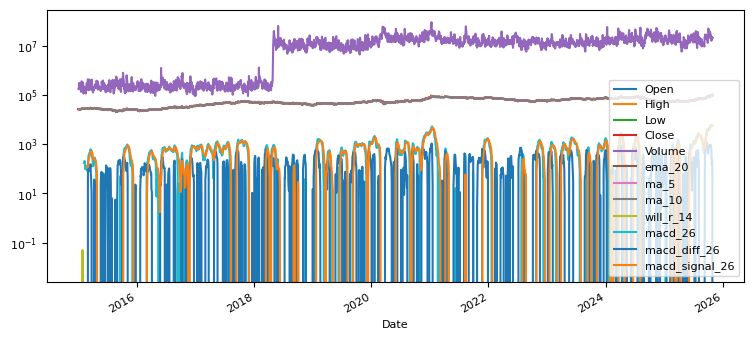

In [16]:
pd_data.plot(y=['Open', 'High', 'Low', 'Close', 'Volume', 'ema_20', 'ma_5', 'ma_10',
        'will_r_14', 'macd_26', 'macd_diff_26', 'macd_signal_26'],
        logy=True,figsize=(9,4) )

In [17]:
import seaborn as sns # Visualization

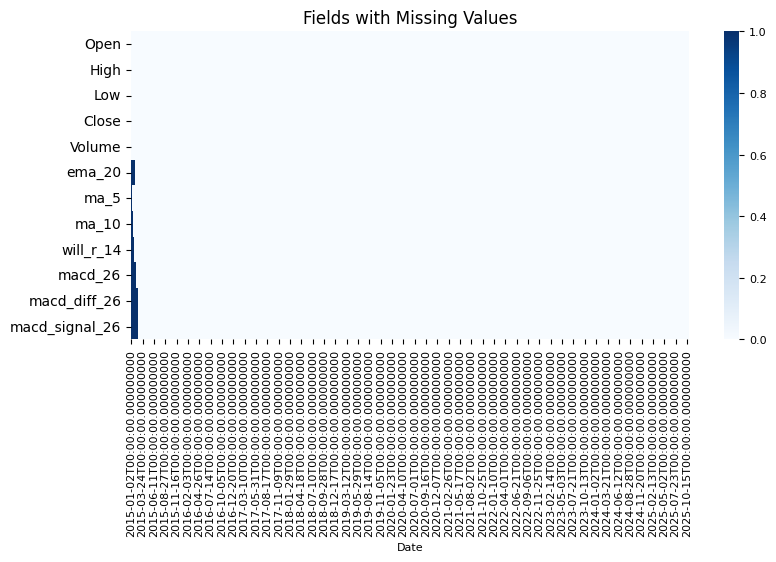

In [18]:
f, ax = plt.subplots(nrows=1, ncols=1, figsize=(9, 4))
sns.heatmap(pd_data.T.isna(), cmap='Blues', ax=ax)
ax.set_title('Fields with Missing Values', fontsize=12)
ax.tick_params(axis='y', labelsize=10)
plt.show()

In [19]:
pd_data.isna().sum()

,0
Open,0
High,0
Low,0
Close,0
Volume,0
ema_20,19
ma_5,4
ma_10,9
will_r_14,13
macd_26,25


In [20]:
# Remove old rows
pd_data = pd_data[pd_data.macd_signal_26.notna()].reset_index(drop=True)
# Remove not usefull columns
pd_data.isna().sum()

,0
Open,0
High,0
Low,0
Close,0
Volume,0
ema_20,0
ma_5,0
ma_10,0
will_r_14,0
macd_26,0


### Preprocessing

In [21]:
#### Scale별로 정규화 하기 ####
def MinMaxScaler(data):
    min_ = np.min(data[:,:4])
    max_ = np.max(data[:,:4])
    data[:,:4] = (data[:,:4] - min_) / (max_ - min_) # price
    data[:,4] = (data[:,4]-np.min(data[:,4])) / (np.max(data[:,4])-np.min(data[:,4]))#volume
    data[:,5:8] = (data[:,5:8] - min_) / (max_ - min_)# ema 5,10, 20
    data[:,8] = (data[:,8]-np.min(data[:,8])) / (np.max(data[:,8])-np.min(data[:,8]))#Will_R
    data[:,9] = (data[:,9]-np.min(data[:,9])) / (np.max(data[:,9])-np.min(data[:,9]))#macd
    data[:,10] = (data[:,10]-np.min(data[:,10])) / (np.max(data[:,10])-np.min(data[:,10]))#macd_diff
    data[:,11] = (data[:,11]-np.min(data[:,11])) / (np.max(data[:,11])-np.min(data[:,11]))#macd siganl
    return data

In [22]:
x_label = ['Open', 'High', 'Low', 'Close', '_5', 'ma_1Volume', 'ema_20', 'ma0',
        'will_r_14', 'macd_26', 'macd_diff_26', 'macd_signal_26']

In [23]:
# pd_data:(date,[Open,High,Low,Close,Volume])
xy = np.array(pd_data) #np <- pandas data format

xy = MinMaxScaler(xy)    # minmax 정규화
XX = xy              # input data(Open,High,Low,Volume,Close)
#y = xy[:,3]         # 종가만 slicing -> target data
#Y = xy             #

# data type 확인
print ("SHAPE OF XX IS %s" % (XX.shape,))


SHAPE OF XX IS (2624, 12)


In [24]:
for i, pred in enumerate(x_label):
    print(f"min:{np.min(XX[:,i]):.4f}, max:{np.max(XX[:,i]):.4f} ,{x_label[i]}")

min:0.0086, max:0.9914 ,Open
min:0.0101, max:1.0000 ,High
min:0.0000, max:0.9828 ,Low
min:0.0084, max:1.0000 ,Close
min:0.0000, max:1.0000 ,_5
min:0.0209, max:0.9000 ,ma_1Volume
min:0.0102, max:0.9688 ,ema_20
min:0.0130, max:0.9596 ,ma0
min:0.0000, max:1.0000 ,will_r_14
min:0.0000, max:1.0000 ,macd_26
min:0.0000, max:1.0000 ,macd_diff_26
min:0.0000, max:1.0000 ,macd_signal_26


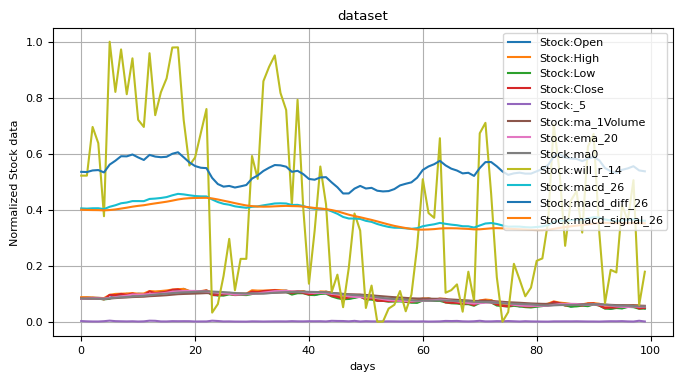

In [25]:
plt.figure(figsize=(8, 4))
for i, pred in enumerate(x_label) :
    plt.plot(XX[:100,i], label="Stock:"+x_label[i])
plt.title("dataset")
plt.xlabel('days')
plt.ylabel('Normalized Stock data')
plt.legend()
plt.grid(True)
plt.show()

### Sequence Data Generation

In [26]:
# sequence generator
def seq_gen_n(x,seq_length):
    dataX = []
    dataY = []
    for i in range(0, len(x) - seq_length):
        _x = x[i:i + seq_length] # 7일치 데이터
        _y = x[i+seq_length, 3] # closing price on the day after the sequence

        dataX.append(_x)
        dataY.append(_y)
    # train data : test data = 9 : 1
    train_size = int(len(dataY) * 0.9)
    test_size  = len(dataY) - train_size
    x_train = np.array(dataX[0:train_size])
    # Reshape y_train and y_test to be (samples, 1) since we predict a single value
    y_train = np.array(dataY[0:train_size]).reshape(-1, 1)
    x_test  = np.array(dataX[train_size:])
    y_test  = np.array(dataY[train_size:]).reshape(-1, 1)
    return x_train,y_train,x_test,y_test

In [27]:
timesteps = seq_length = 20
x_train,y_train,x_test,y_test = seq_gen_n(XX,seq_length)

ps(x_train,'x_train')
ps(y_train,'y_train')
ps(x_test,'x_test')
ps(y_test,'y_test')

[x_train] Shape(2343, 20, 12)
[y_train] Shape(2343, 1)
[x_test] Shape(261, 20, 12)
[y_test] Shape(261, 1)


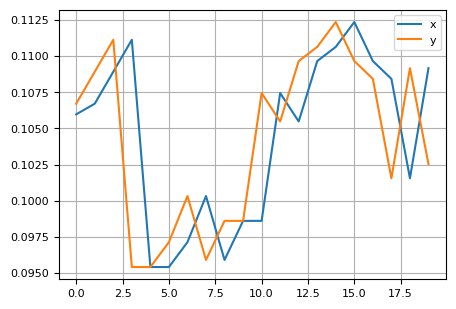

In [28]:
plt.plot(x_train[19,:,3],label="x")
plt.plot(y_train[0:20,0],label="y")

plt.legend()
plt.grid()
plt.show()

In [29]:
class CustomDataset(Dataset):
    def __init__(self, x, y):
        super().__init__()
        self.x = x
        self.y = y
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        return torch.FloatTensor(self.x[idx]),torch.FloatTensor(self.y[idx])

In [30]:
batch_size = 64

trainDataset = CustomDataset(x_train, y_train)
testDataset = CustomDataset(x_test, y_test)
trainDataLoader = DataLoader(trainDataset, batch_size, shuffle=True) # defalut : drop_last=False
testDataLoader = DataLoader(testDataset, batch_size, shuffle=False)

In [31]:
class Wrap_regression(L.LightningModule):
    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = F.mse_loss(y_pred, y)
        mape = FM.mean_absolute_percentage_error(y_pred, y)
        metrics={'loss':loss, 'mape':mape}
        self.log_dict(metrics,prog_bar=True,on_step=False,on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = F.mse_loss(y_pred, y)
        mape = FM.mean_absolute_percentage_error(y_pred, y)
        metrics={'val_loss':loss, 'val_mape':mape}
        self.log_dict(metrics,prog_bar=True,on_step=False,on_epoch=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.005)

## Base Model

In [ ]:
in_dense = 32
hidden_dim = 32
ff = 16
data_dim  = x_train.shape[2] #input_features = data_dim = 12
hidden_dim,data_dim

(32, 12)

In [ ]:
# Multi-Head Attention를 사용하는 LSTM 모델
class LSTMMultiheadAttentionModel(Wrap_regression):
    def __init__(self, input_features, hidden_dim, num_layers=2, output_size=1, num_heads=4):
        super(LSTMMultiheadAttentionModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_heads = num_heads
        self.in_dense = nn.Linear(input_features,in_dense)
        # LSTM 레이어
        self.lstm = nn.LSTM(in_dense, hidden_dim, num_layers, dropout=0.2, batch_first=True)
        # Multihead Attention 레이어
        self.multihead_attn = nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=num_heads, batch_first=True)
        # MultiheadAttention 출력 : (batch, seq_len, hidden_dim)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, ff),
            nn.ReLU(),
            nn.Linear(ff, 1),
        )

    def forward(self, x):
        # x: (batch_size, seq_len, input_features)
        x = self.in_dense(x)
        # LSTM 레이어
        lstm_out, (hn, cn) = self.lstm(x)
        attn_output, attn_output_weights = self.multihead_attn(query=lstm_out, key=lstm_out, value=lstm_out)
        # attn_output은 각 시점의 어텐션이 적용된 결과이므로,
        # 시계열 전체를 대표하는 하나의 벡터로 압축해야 함
        output = self.fc(attn_output) # 최종 예측값
        return output[:,-1,:] #, attn_output_weights # 어텐션 가중치를 반환할 수도 있음

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.005)

# batch_size = 64
# seq_len = 7
# input_features_example = 12 # data_dim과 동일

# 모델 생성
model_Att = LSTMMultiheadAttentionModel(data_dim, hidden_dim,num_layers=1)
summary(model_Att, input_size=x_train[:batch_size].shape) #(64,7,12)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


Layer (type:depth-idx)                   Output Shape              Param #
LSTMMultiheadAttentionModel              [64, 1]                   --
├─Linear: 1-1                            [64, 20, 32]              416
├─LSTM: 1-2                              [64, 20, 32]              8,448
├─MultiheadAttention: 1-3                [64, 20, 32]              4,224
├─Sequential: 1-4                        [64, 20, 1]               --
│    └─Linear: 2-1                       [64, 20, 16]              528
│    └─ReLU: 2-2                         [64, 20, 16]              --
│    └─Linear: 2-3                       [64, 20, 1]               17
Total params: 13,633
Trainable params: 13,633
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 10.87
Input size (MB): 0.06
Forward/backward pass size (MB): 0.83
Params size (MB): 0.04
Estimated Total Size (MB): 0.93

In [ ]:
model_Att

LSTMMultiheadAttentionModel(
  (in_dense): Linear(in_features=12, out_features=32, bias=True)
  (lstm): LSTM(32, 32, batch_first=True, dropout=0.2)
  (multihead_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
  )
  (fc): Sequential(
    (0): Linear(in_features=32, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=1, bias=True)
  )
)

In [40]:
from lightning.pytorch.callbacks import ModelCheckpoint

In [ ]:
%%time
#model_Att = model_Att(data_dim, hidden_dim)
name = "model_Att"

checkpoint_callback = ModelCheckpoint(dirpath='./aicamp', monitor='val_loss')
logger = CSVLogger("logs", name=name)
trainer = Trainer(max_epochs=100, logger=logger,callbacks=[checkpoint_callback])
trainer.fit(model_Att, trainDataLoader, testDataLoader)
checkpoint = torch.load(checkpoint_callback.best_model_path)
model_Att.load_state_dict(checkpoint['state_dict'])
model_Att.eval()

Wall time: 1min 2s


In [42]:
v_num = logger.version
history = pd.read_csv(f'./logs/{name}/version_{v_num}/metrics.csv')
dfAtt = history.groupby('epoch').last().drop('step', axis=1)

In [43]:
def plt_history(historys,names):
    mins =[]
    title_name = ""
    for i,h in enumerate(historys):
        title_name += f"({names[i]}:{min(h['val_mape'])*100:.3f})"
    plt.figure(figsize=(12,3))
    plt.subplot(131)
    for i,h in enumerate(historys):
        plt.plot(h['loss'], label=names[i])
    plt.title("Training loss")
    #plt.ylim(0.1, 1)
    plt.semilogy()
    plt.legend()
    plt.grid()

    plt.subplot(132)
    plt.title("validation loss")
    for i,h in enumerate(historys):
        plt.plot(h['val_loss'], label=names[i])
    #plt.ylim(0.1, 1)
    plt.semilogy()
    plt.legend()
    plt.grid()

    plt.subplot(133)
    plt.title(f"validation mape\n{title_name}")
    for i,h in enumerate(historys):
        plt.plot(h['val_mape'], label=names[i])
    #plt.ylim(0.1, 1)
    plt.semilogy()
    plt.legend()
    plt.grid()
    plt.show()

In [ ]:
titles=["dfAtt"]
plt_history([dfAtt],titles)

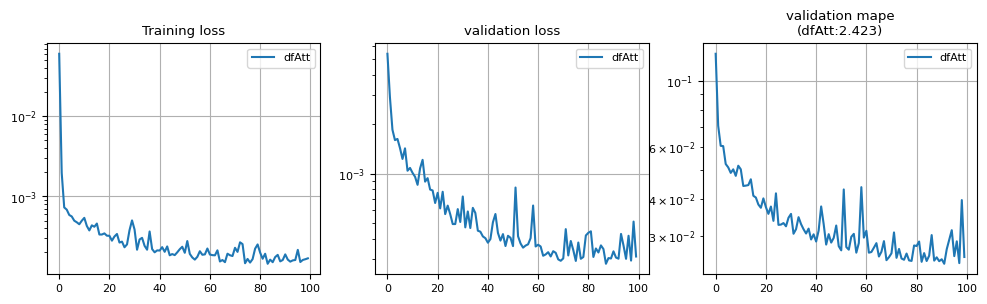